In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from pybedtools import BedTool
from glob import glob
from multiprocessing import Pool, cpu_count
from typing import List, Tuple, Dict, Mapping, Union, Literal
import pyranges as pr
import numpy.typing as npt
from functools import partial

/home/orion/miniconda3/envs/omics/lib/python3.10/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [5]:
def read_bed_file(file: str) -> pd.DataFrame:
    return pd.read_csv(file, sep = '\t', 
                       header = None, 
                       names=['Chromosome', 'Start', 'End', 'Score', 'Mindpoint'], 
                       skiprows = 1)

def parse_and_merge_bed(input_files: str, 
                        return_type: Literal["bed", "pyranges", "dataframe"] = "dataframe" 
                       ) -> Union[BedTool, pd.DataFrame, pr.PyRanges]:
    file_paths = glob(input_files, recursive=True)
    with Pool(processes=cpu_count() // 2) as pool:
        dfs = pool.map(read_bed_file, file_paths)
    merged_df = pd.concat(dfs, ignore_index=True).sort_values(by=["Chromosome", "Start"]).reset_index().iloc[:, 1:]
    match return_type:
        case "bed":
            return BedTool.from_dataframe(merged_df)
        case "dataframe":
            return merged_df
        case "pyranges":
            return pr.PyRanges(merged_df)
        case _:
            raise ValueError(f"Unknown return_type: {return_type}")

rec_rate_10kb = parse_and_merge_bed("../output/transformed_*_w10000.tsv", return_type="bed")

In [6]:
def transform_feature_table(
    gff_object: Union[pd.DataFrame, BedTool, pr.PyRanges],
    chr_pattern: str = r"chr([1-9]|[12][0-9]|3[0-3])$",
    return_type: Literal["bed", "dataframe", "pyranges"] = "dataframe"
) -> Union[BedTool, pd.DataFrame, pr.PyRanges]:
    if isinstance(gff_object, BedTool):
        gff = gff_object.to_dataframe()
    elif isinstance(gff_object, pd.DataFrame):
        gff = gff_object.copy()
    elif isinstance(gff_object, pr.PyRanges):
        gff = gff_object.df
    else:
        raise TypeError("Input must be a pandas DataFrame or a BedTool object")

    required_columns: List[str] = ["chromosome", "start", "end", "# feature", "name", "symbol"]
    missing = set(required_columns) - set(gff.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    df_transformed = (
        gff
        .filter(items=required_columns)
        .assign(
            start=lambda df: df["start"].astype("int64"),
            end=lambda df: df["end"].astype("int64"),
            chromosome=lambda df: "chr" + df["chromosome"].astype(str)
        )
        .loc[lambda df: df["chromosome"].str.match(chr_pattern)]
    )

    # Rename 'chromosome' to 'chrom' because BedTool expects 'chrom' as the first column
    df_transformed = df_transformed.rename(
        columns={"chromosome": "Chromosome",
                 "start": "Start",
                 "end": "End",
                 "# feature": "Feature",
                 "symbol": "Symbol",
                 "name": "Name"})

    # Reorder columns so that chrom, start, end are first 3 columns (required for BedTool)
    bedtool_columns = ["Chromosome", "Start", "End", "Feature", "Name","Symbol"]
    df_transformed = df_transformed[bedtool_columns]
    df_sorted = df_transformed.sort_values(by=["Chromosome", "Start"]).reset_index(drop=True)

    match return_type:
        case "bed":
            return BedTool.from_dataframe(df_sorted)
        case "dataframe":
            return df_sorted
        case "pyranges":
            return pr.PyRanges(df_sorted)
        case _:
            raise ValueError(f"Unknown return_type: {return_type}")


blackcap_feature_table = pd.read_csv("../input/GCF_009819655.1_bSylAtr1.pri_feature_table.txt", sep = '\t', header = 0, dtype=str)

blackcap_gff = transform_feature_table(blackcap_feature_table, return_type="bed")
blackcap_genes = blackcap_gff.filter(lambda x: x.name in ("gene", "mRNA", "CDS")).sort()

In [7]:
def split_bedtool_by_feature(input_bed: pr.PyRanges | pd.DataFrame | BedTool,
                             return_type: Literal["bed", "dataframe", "pyranges"]) -> dict[str, Union[pr.PyRanges, BedTool, pd.DataFrame]]:
    
    if isinstance(input_bed, pr.PyRanges):
        df = input_bed.df
    elif isinstance(input_bed, pd.DataFrame):
        df = input_bed.copy()
    elif isinstance(input_bed, BedTool):
        df = input_bed.to_dataframe()
    else:
        raise TypeError("Input must be a PyRanges, pandas DataFrame, or BedTool object")
    
    if df.shape[1] < 4:
        raise ValueError("Expected at least 4 columns in the BedTool Data Format (chrom, start, end, features)")

    feature_dict: Dict[str, Union[BedTool, pd.DataFrame, pr.PyRanges]] = {}

    unique_features = df.iloc[:, 3].unique()
    for feature in unique_features:
        df_feature = df[df.iloc[:, 3] == feature]
        if return_type == "bed":
            feature_dict[feature] = BedTool.from_dataframe(df_feature)
        elif return_type == "dataframe":
            feature_dict[feature] = df_feature
        elif return_type == "pyranges":
            feature_dict[feature] = pr.PyRanges(df_feature)
        else:
            raise ValueError(f"Unknown return_type: {return_type}")

    return feature_dict


blackcap_genes = split_bedtool_by_feature(blackcap_genes, return_type="dataframe")

In [8]:
rho_gff_intersections = (
    rec_rate_10kb.intersect(blackcap_gff, wb=True)
    .sort()
    .to_dataframe()
    .rename(columns={"name": "cM_Mb",
                     "itemRgb": "feature",
                     "blockCount": "symbol",
                     "blockSizes": "description"
                    })
        )

rho_gff_intersections.head()
rho_gff_intersections['rho_strength'] = pd.qcut(rho_gff_intersections["cM_Mb"], q=3, labels=['low','medium','high']).astype("category")
rho_gff_intersections.head()

,chrom,start,end,cM_Mb,score,strand,thickStart,thickEnd,feature,symbol,description,rho_strength
0,chr1,12841,20000,7.233462,15000,chr1,12841,20557,ncRNA,"uncharacterized lncRNA, transcript variant X2",LOC136375641,medium
1,chr1,12841,20000,7.233462,15000,chr1,12841,20557,gene,uncharacterized LOC136375641,LOC136375641,medium
2,chr1,14799,20000,7.233462,15000,chr1,14799,20557,ncRNA,"uncharacterized lncRNA, transcript variant X1",LOC136375641,medium
3,chr1,20000,20557,2.388083,25000,chr1,12841,20557,gene,uncharacterized LOC136375641,LOC136375641,low
4,chr1,20000,20557,2.388083,25000,chr1,14799,20557,ncRNA,"uncharacterized lncRNA, transcript variant X1",LOC136375641,low


In [9]:
feature_counts = (
    rho_gff_intersections.groupby(['feature', 'rho_strength'])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)
feature_counts["percent_intersections"] = ((feature_counts["count"] / feature_counts["count"].sum()).round(6))*100

feature_counts['feature'] = feature_counts["feature"].str.replace('_', ' ')
feature_counts.head(20)

/tmp/ipykernel_180882/532279005.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rho_gff_intersections.groupby(['feature', 'rho_strength'])


,feature,rho_strength,count,percent_intersections
0,mRNA,medium,46712,13.6999
1,mRNA,high,46229,13.5582
2,mRNA,low,46007,13.4931
3,CDS,low,41221,12.0894
4,CDS,high,40909,11.9979
5,CDS,medium,40828,11.9742
6,gene,high,23047,6.7593
7,gene,medium,22538,6.6100
8,gene,low,22281,6.5346
9,ncRNA,low,2929,0.8590


In [1]:
fig = px.bar(
    feature_counts,
    x = 'feature',
    y ='percent_intersections',
    color = "rho_strength",
    title ='% Intersections of Recombination Rate windows per Genomic Feature',
    labels = {'feature': 'Genomic Feature', 'percent_intersections': 'Percent of Intersections', 'rho_strength': 'Recombination Rate'}
)
fig.update_traces(textfont_size=16)
fig.update_layout(yaxis_title="% of Total Intersections", 
                  legend = dict(
                      font = dict(size=16)
                  ),
                 title = dict(
                     font=dict(size=20)
                 ))
fig.show(renderer="iframe")

NameError: name 'px' is not defined

In [ ]:
blackcap_genome = (
    pd.read_csv("../input/SylAtri_genome.txt.tsv", sep="\t", usecols=['Chromosome name', 'Seq length'])
    .assign(**{'Chromosome name': lambda df: 'chr' + df['Chromosome name'].astype(str)})
    .head(33)
)

,Chromosome name,Seq length
0,chr1,153194430
1,chr2,115287908
2,chr3,113359798
3,chr4,72978054
4,chr5,72605035
5,chr6,63423007
6,chr7,38862568
7,chr8,35969369
8,chr9,31650914
9,chr10,26389481


In [3]:
class JaccardCalculator:
    __slots__ = ("chromsizes",)

    def __init__(self, chromsizes: str):
        self.chromsizes = self._load_chromsizes(chromsizes)

    @staticmethod
    def _load_chromsizes(chromsizes: str) -> dict:
        df = pd.read_csv(chromsizes, sep="\t", header=None, names=["chrom", "size"])
        return {row["chrom"]: (0, row["size"]) for _, row in df.iterrows()}

    @staticmethod
    def to_bedtool(obj: Union[pr.PyRanges, BedTool, pd.DataFrame]) -> BedTool:
        if isinstance(obj, BedTool):
            return obj.sort()
        elif isinstance(obj, pr.PyRanges):
            return BedTool.from_dataframe(obj.df).sort()
        elif isinstance(obj, pd.DataFrame):
            return BedTool.from_dataframe(obj).sort()
        else:
            raise TypeError("Input must be PyRanges, BedTool, or pandas DataFrame")

    @staticmethod
    def _single_iter(args):
        bed1_df, bed2_df, chromsizes = args
        shuffled_bed1 = BedTool.from_dataframe(bed1_df).shuffle(genome=chromsizes, chrom=True).sort()
        return shuffled_bed1.jaccard(BedTool.from_dataframe(bed2_df))["jaccard"]

    def shuffle_intervals(self, bed1_df: pd.DataFrame, bed2_df: pd.DataFrame, iterations: int) -> npt.NDArray[np.float64]:
        args = [(bed1_df, bed2_df, self.chromsizes)] * iterations
        with Pool(processes=cpu_count()) as pool:
            results = pool.map(self._single_iter, args)
        return np.array(results, dtype=np.float64)

    @staticmethod
    def empirical_pvalue_two_tailed(observed: float, null: List[float] | npt.NDArray[np.float64]) -> float:
        if not isinstance(null, np.ndarray):
            null = np.asarray(null, dtype=np.float64)
        null_mean = null.mean()
        diff_obs = abs(observed - null_mean)
        p_val = (np.sum(np.abs(null - null_mean) >= diff_obs) + 1) / (len(null) + 1)
        return p_val

    def compute_jaccard(
        self,
        bed_input1: Union[pr.PyRanges, BedTool, pd.DataFrame],
        bed_input2: Union[pr.PyRanges, BedTool, pd.DataFrame, Mapping[str, Union[pr.PyRanges, BedTool, pd.DataFrame]]],
        iterations: int = 1000
    ) -> pd.DataFrame:

        bed1 = self.to_bedtool(bed_input1)
        bed1_df = bed1.to_dataframe()

        if isinstance(bed_input2, Mapping):
            bed2_dict = {k: self.to_bedtool(v) for k, v in bed_input2.items()}
        else:
            bed2 = self.to_bedtool(bed_input2)
            feature_name = (
                bed_input2.df.iloc[0, 3]
                if isinstance(bed_input2, pr.PyRanges) and bed_input2.df.shape[1] > 3
                else bed_input2.iloc[0, 3]
                if isinstance(bed_input2, pd.DataFrame) and bed_input2.shape[1] > 3
                else "feature"
            )
            bed2_dict = {feature_name: bed2}

        records = []
        for feature, bed2 in bed2_dict.items():
            bed2_df = bed2.to_dataframe()
            observed_jaccard = bed1.jaccard(bed2)["jaccard"]
            shuffled_jaccards: npt.NDArray[np.float64] = self.shuffle_intervals(bed1_df, bed2_df, iterations)

            ci_lower = np.percentile(shuffled_jaccards, 2.5)
            ci_upper = np.percentile(shuffled_jaccards, 97.5)
            mean = shuffled_jaccards.mean()
            median = np.median(shuffled_jaccards)
            pval = self.empirical_pvalue_two_tailed(observed_jaccard, shuffled_jaccards)

            records.append({
                "feature": feature,
                "observed_jaccard": observed_jaccard,
                "shuffled_jaccard_mean": mean,
                "shuffled_jaccard_median": median,
                "ci_lower_95%": ci_lower,
                "ci_upper_95%": ci_upper,
                "p_value_two_tailed": pval
            })

        return pd.DataFrame(records)

blackcap = JaccardCalculator("../input/blackcap.genome")
jaccard_results = blackcap.compute_jaccard(bed_input1=rec_rate_10kb, bed_input2=blackcap_genes, iterations=1000)

NameError: name 'Union' is not defined

In [2]:

# Calculate error bar lengths relative to the mean
jaccard_results['error_lower'] = jaccard_results['jaccard_mean'] - jaccard_results['ci_lower_95%']
jaccard_results['error_upper'] = jaccard_results['ci_upper_95%'] - jaccard_results['jaccard_mean']

df_long = pd.melt(
    jaccard_results,
    id_vars=["feature"],
    value_vars=["jaccard_mean", "observed_jaccard"],
    var_name="Legend",
    value_name="Jaccard_Index"
)

fig = px.bar(
    df_long,
    x="feature",
    y="Jaccard_Index",
    color="Legend",
    barmode="group",
    title="Comparison of Jaccard Metrics by Feature",
    labels={"feature": "Genomic Feature", "Jaccard_Index": "Jaccard Index"},
    width=900,
    height=600,
)

fig.show()



NameError: name 'jaccard_results' is not defined

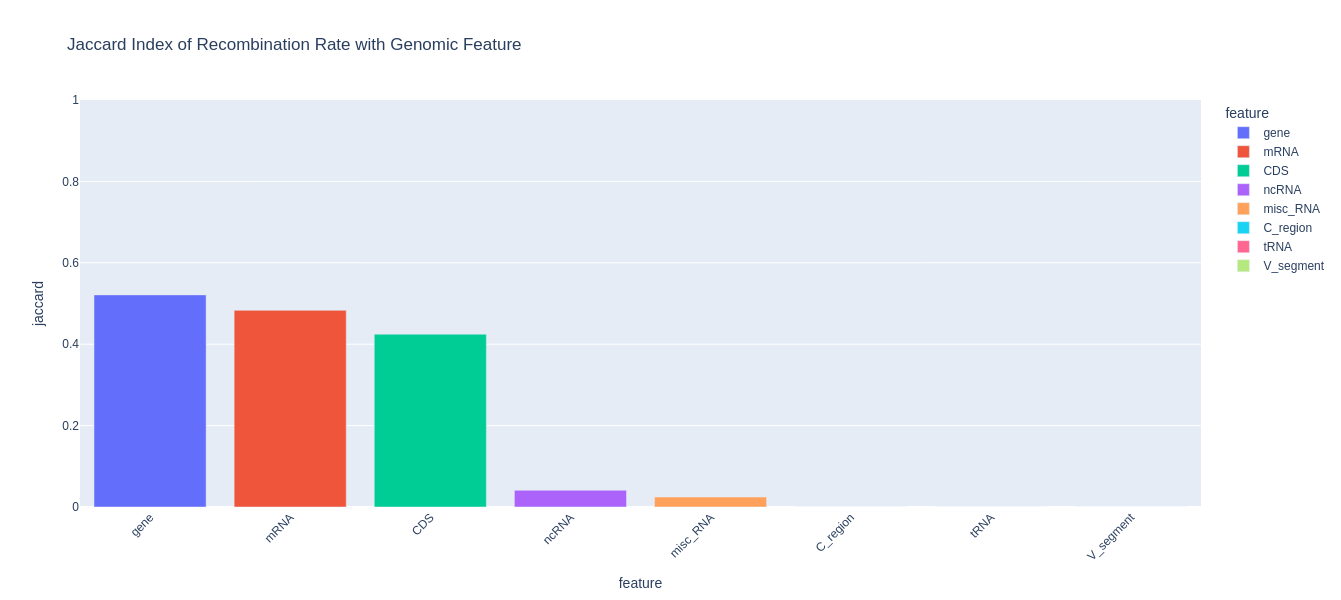

In [27]:
fig = px.bar(
    jaccard_list,
    x = "feature",
    y = "jaccard",
    title="Jaccard Index of Recombination Rate with Genomic Feature",
    width=900,
    height=600,
    color="feature"
)

fig.update_layout(
    yaxis=dict(range=[0, 1]),
    xaxis_tickangle=-45,
)

fig.show()

In [32]:
print(str(len(rec_rate_10kb)))
for feature, bed in features.items():
    print("\t".join([feature, str(len(bed))]))

94208
gene	16457
ncRNA	2172
mRNA	26215
CDS	26222
misc_RNA	643
tRNA	217
C_region	4
V_segment	3


In [83]:
gff = pr.read_gff3("../input/bSylAtr1.pri.gff")
chromosome_labels = dict(
    pd.read_csv("../input/SylAtri_genome.txt.tsv", sep="\t", header=0)
      .loc[:, ["RefSeq seq accession", "Chromosome name"]]
      .dropna()
      .assign(**{"Chromosome name": lambda df: "chr" + df["Chromosome name"].astype(str)})
      .values
)
gff.head()

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,ID,Dbxref,...,pct_identity_gap,pct_identity_ungap,rank,Gap,standard_name,map,Is_circular,tissue-lib,codons,transl_table
0,NC_010228.1,RefSeq,region,0,17937,.,+,.,NC_010228.1:1..17937,taxon:48155,...,NaN,NaN,NaN,NaN,NaN,NaN,true,X-047,NaN,NaN
1,NC_010228.1,RefSeq,gene,0,70,.,+,.,gene-tRNA-Phe,GeneID:5846186,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NC_010228.1,RefSeq,tRNA,0,70,.,+,.,rna-tRNA-Phe,GeneID:5846186,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NC_010228.1,RefSeq,exon,0,70,.,+,.,exon-tRNA-Phe-1,GeneID:5846186,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NC_010228.1,RefSeq,gene,70,1046,.,+,.,gene-12S rRNA,GeneID:5846199,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NC_010228.1,RefSeq,rRNA,70,1046,.,+,.,rna-12S rRNA,GeneID:5846199,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NC_010228.1,RefSeq,exon,70,1046,.,+,.,exon-12S rRNA-1,GeneID:5846199,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NC_010228.1,RefSeq,gene,1046,1116,.,+,.,gene-tRNA-Val,GeneID:5846218,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
gff = pr.PyRanges(gff.df.pipe(lambda df: df.assign(Chromosome=df["Chromosome"].map(chromosome_labels)).dropna(subset=["Chromosome"])))
print(gff.head())
gff_subset = pr.PyRanges(
    gff.df.pipe(lambda df: df[(df["Feature"] == "gene") & (df["Chromosome"].str.match(r"chr(?:[1-9]|[1-2][0-9]|3[0-3])"))])[["Chromosome", "Start", "End", "Strand", "Feature", "Name"]]
)
gff_subset

+--------------+------------+------------+-----------+-----------+-------+
| Chromosome   | Source     | Feature    |     Start |       End | +52   |
| (category)   | (object)   | (object)   |   (int64) |   (int64) | ...   |
|--------------+------------+------------+-----------+-----------+-------|
| chr1         | RefSeq     | region     |         0 | 153194430 | ...   |
| chr1         | Gnomon     | gene       |    112199 |    122771 | ...   |
| chr1         | Gnomon     | mRNA       |    112199 |    122771 | ...   |
| chr1         | Gnomon     | exon       |    112199 |    112336 | ...   |
| chr1         | Gnomon     | exon       |    112574 |    112742 | ...   |
| chr1         | Gnomon     | exon       |    115090 |    115303 | ...   |
| chr1         | Gnomon     | exon       |    116209 |    116392 | ...   |
| chr1         | Gnomon     | exon       |    116697 |    116869 | ...   |
+--------------+------------+------------+-----------+-----------+-------+
Stranded PyRanges object 

,Chromosome,Start,End,Strand,Feature,Name
0,chr1,112199,122771,+,gene,ABCF2
1,chr1,126172,127619,+,gene,H2BK1
2,chr1,135232,143451,+,gene,ASB10
3,chr1,155021,161918,+,gene,GBX1
4,chr1,285154,287123,+,gene,TMUB1
...,...,...,...,...,...,...
16231,chr33,173275,173749,-,gene,LOC136373226
16232,chr33,186098,186458,-,gene,LOC136373218
16233,chr33,201295,202041,-,gene,LOC136373188
16234,chr33,237392,239411,-,gene,LOC136373190


In [104]:
rec_rate_10kb.df[rec_rate_10kb.df["Chromosome"] == "chr1"][["Chromosome", "Score"]].sort_values(by="Score", ascending=False)


,Chromosome,Score
15154,chr1,196.653177
15150,chr1,183.419222
113,chr1,178.045426
15159,chr1,170.818489
112,chr1,164.206686
...,...,...
5686,chr1,0.010768
5685,chr1,0.010689
5696,chr1,0.009107
5695,chr1,0.009107
